In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import os
import matplotlib as mpl

# Load Data 

In [2]:
Genta=pd.read_csv('Tables/Gentamicin.csv')
Chp=pd.read_csv('Tables/Chloramphenicol.csv')
Tetra=pd.read_csv('Tables/Tetracycline.csv')
Cipro=pd.read_csv('Tables/Ciprofloxacin.csv')

In [3]:
qzero_threshold=0.6
Genta.drop(Genta[Genta['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Chp.drop(Chp[Chp['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Tetra.drop(Tetra[Tetra['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)
Cipro.drop(Cipro[Cipro['prob_neg_drop_zero_det']<qzero_threshold].index,inplace=True)

In [4]:
Genta_f=pd.read_csv('Tables/Gentamicin_Fit.csv',index_col=0)
Chp_f=pd.read_csv('Tables/Chloramphenicol_Fit.csv',index_col=0)
Tetra_f=pd.read_csv('Tables/Tetracycline_Fit.csv',index_col=0)
Cipro_f=pd.read_csv('Tables/Ciprofloxacin_Fit.csv',index_col=0)

In [5]:
xmax=[2.04,8.2,104.04,16.5]
xmin=[-0.08,-0.2,-4,-0.7]

# Calculate MBC, MIC, ratio, PAP measurment

In [6]:
b=np.array([Genta_f['b'].values[0],Cipro_f['b'].values[0],Chp_f['b'].values[0],Tetra_f['b'].values[0],Tetra_f['b'].values[4]])

birth_mean=1/3
T=24
alpha=np.array([20,200])
q_MIC=1-np.log(alpha)/(birth_mean*T)

MBC= np.power(-np.log((1 - 0.999)/(1-0.25)),  1 / b[:, np.newaxis])
MIC= np.power(-np.log((1 - q_MIC)/(1-0.25)), 1 / b[:, np.newaxis])
ratio=MBC/MIC


lamb=np.power(10,5)
q_0=0.25
c=np.arange(0,10,0.0001)
s= (1-q_0) * np.exp(-np.power(c, b[:, np.newaxis]))

# Plot

In [10]:
# Define once, use everywhere
standard_linewidth = 1.5  # Choose a value that looks good

spinesParams = {
    'axes.spines.right': True,
    'axes.spines.top': True,
    'axes.linewidth': standard_linewidth,
}



tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}
tickParams = {
    "xtick.top":True,
    "xtick.bottom":True,
    "xtick.direction": "in",
    "ytick.left":True,
    "ytick.right":True,
    "ytick.direction": "in",
}
spinesParams = {
    'axes.spines.right' : True,
    'axes.spines.top' : True
}
plt.rcParams.update(tex_fonts)
plt.rcParams.update(tickParams)
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
plt.rcParams.update(spinesParams)  # ADD THIS LINE

inchPerCm = 0.393701
goldenRatio = (1+np.sqrt(5))/2
figWidthCm = 17.9
figHeightCm = figWidthCm/1.2
#figHeightCm = figWidthCm*1.2

figWidthInches = figWidthCm*inchPerCm
figHeightInches = figHeightCm*inchPerCm

colors=sns.color_palette("colorblind")
markers=['o','s','<','v','h','P','*','^','8','p','H','d','D','X']
marker_size=5

lw=2
lw2=1

In [11]:
fig_label_x=-0.15
fig_label_y=1

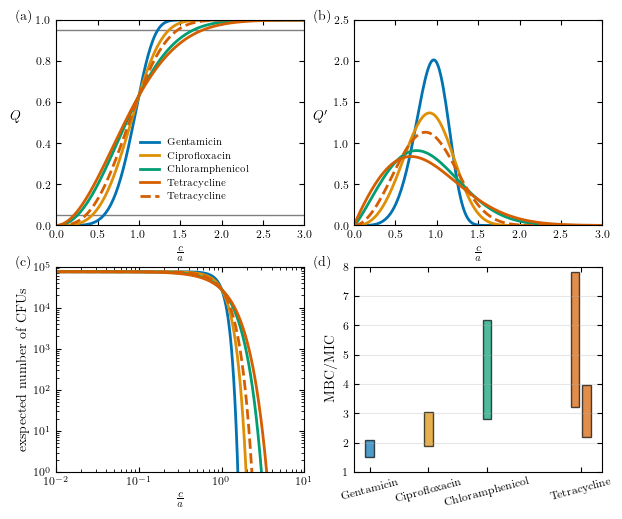

In [124]:
x_fitted = np.linspace(0, 150, 10000)
marker_size=5
fig_label_x_1=-0.16
fig_label_y_1=1
fig, ax = plt.subplots(2,2, figsize=(figWidthInches, figHeightInches))
ax[0,0].plot([0,3],[0.05,0.05], color='gray',linewidth=1)
ax[0,0].plot([0,3],[0.95,0.95], color='gray',linewidth=1)
ax[0,0].plot(x_fitted,1- np.exp(-np.power(x_fitted,Genta_f['b'].values[0])), color=colors[0],linewidth=lw,label='Gentamicin')
ax[0,0].plot(x_fitted,1- np.exp(-np.power(x_fitted,Cipro_f['b'].values[0])), color=colors[1],linewidth=lw,label='Ciprofloxacin')
ax[0,0].plot(x_fitted,1- np.exp(-np.power(x_fitted,Chp_f['b'].values[0])), color=colors[2],linewidth=lw,label='Chloramphenicol')
ax[0,0].plot(x_fitted,1-np.exp(-np.power(x_fitted,Tetra_f['b'].values[0])), color=colors[3],linewidth=lw,label='Tetracycline')
ax[0,0].plot(x_fitted,1- np.exp(-np.power(x_fitted,Tetra_f['b'].values[4])), color=colors[3],linewidth=lw,linestyle='--',label='Tetracycline')
        
ax[0,0].set_ylabel(r'$Q$',rotation=0, labelpad=15)
ax[0,0].set_xlabel(r'$\frac{c}{a}$')
ax[0,0].set_xlim([0,3])
ax[0,0].set_ylim([0,1])

ax[0,1].plot(x_fitted,Genta_f['b'].values[0]* np.power(x_fitted,Genta_f['b'].values[0]-1) * np.exp(-np.power(x_fitted,Genta_f['b'].values[0])), color=colors[0],linewidth=lw,label='Gentamicin')
ax[0,1].plot(x_fitted,Cipro_f['b'].values[0]*np.power(x_fitted,Cipro_f['b'].values[0]-1) * np.exp(-np.power(x_fitted,Cipro_f['b'].values[0])), color=colors[1],linewidth=lw,label='Ciprofloxacin')
ax[0,1].plot(x_fitted,Chp_f['b'].values[0]*np.power(x_fitted,Chp_f['b'].values[0]-1) * np.exp(-np.power(x_fitted,Chp_f['b'].values[0])), color=colors[2],linewidth=lw,label='Chloramphenicol')
ax[0,1].plot(x_fitted,Tetra_f['b'].values[0]*np.power(x_fitted,Tetra_f['b'].values[0]-1) * np.exp(-np.power(x_fitted,Tetra_f['b'].values[0])), color=colors[3],linewidth=lw,label='Tetracycline')
ax[0,1].plot(x_fitted,Tetra_f['b'].values[4]*np.power(x_fitted,Tetra_f['b'].values[4]-1) * np.exp(-np.power(x_fitted,Tetra_f['b'].values[4])), color=colors[3],linewidth=lw,linestyle='--',label='Tetracycline')
        
ax[0,1].set_ylabel(r'$Q^\prime$',rotation=0, labelpad=10)
ax[0,1].set_xlabel(r'$\frac{c}{a}$')
ax[0,1].set_xlim([0,3])
ax[0,1].set_ylim([0,2.5])

ax[0,0].legend(frameon=False,loc=(0.32,0.1))

#------------------------------------------------


ax[1,0].plot(c,lamb *s[0,:],color=colors[0],linewidth=lw)
ax[1,0].plot(c,lamb *s[1,:],color=colors[1],linewidth=lw)
ax[1,0].plot(c,lamb *s[2,:],color=colors[2],linewidth=lw)
ax[1,0].plot(c,lamb *s[3,:],color=colors[3],linewidth=lw)
ax[1,0].plot(c,lamb *s[4,:],color=colors[3],linestyle='--',linewidth=lw)

ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')

ax[1,0].set_xlim([0.01,10])
ax[1,0].set_ylim([1,100000])
ax[1,0].set_xlabel(r'$\frac{c}{a}$')
ax[1,0].set_ylabel(r'exspected number of CFUs')


#------------------------------------------------
x_positions = [0, 1, 2, 3.5, 3.7]  # Tetracycline samples closer together
x_ticks = [0, 1, 2, 3.6]
labels = ['Gentamicin', 'Ciprofloxacin', 'Chloramphenicol', 'Tetracycline']



ax[1,1].bar(x_positions[0], height= ratio[0, 1]- ratio[0, 0], bottom=ratio[0, 0], 
              width=0.15, color=colors[0], alpha=0.7, edgecolor='black')
ax[1,1].bar(x_positions[1], height= ratio[1, 1]- ratio[1, 0], bottom=ratio[1, 0], 
              width=0.15, color=colors[1], alpha=0.7, edgecolor='black')
ax[1,1].bar(x_positions[2], height= ratio[2, 1]- ratio[2, 0], bottom=ratio[2, 0], 
              width=0.15, color=colors[2], alpha=0.7, edgecolor='black')
ax[1,1].bar(x_positions[3], height= ratio[3, 1]- ratio[3, 0], bottom=ratio[3, 0], 
              width=0.15, color=colors[3], alpha=0.7, edgecolor='black')
ax[1,1].bar(x_positions[4], height= ratio[4, 1]- ratio[4, 0], bottom=ratio[4, 0], 
              width=0.15, color=colors[3], alpha=0.7, edgecolor='black')



ax[1,1].set_xticks(x_ticks)
ax[1,1].set_xticklabels(labels, rotation=15, ha='center')
ax[1,1].set_ylabel('MBC/MIC')
ax[1,1].grid(axis='y', alpha=0.3)
ax[1,1].set_ylim([1, 8])

#------------------------------------------------
ax[0,0].text(fig_label_x_1, fig_label_y_1, '(a)', transform=ax[0,0].transAxes)
ax[0,1].text(fig_label_x_1, fig_label_y_1, '(b)', transform=ax[0,1].transAxes)
ax[1,1].text(fig_label_x_1, fig_label_y_1, '(c)', transform=ax[1,0].transAxes)
ax[1,0].text(fig_label_x_1, fig_label_y_1, '(d)', transform=ax[1,1].transAxes)

#plt.tight_layout(w_pad=0.1)
plt.show()

In [125]:
baseSavePath=''
saveFigPath = os.path.join(baseSavePath, 'Figure5.pdf')
fig.savefig(saveFigPath,bbox_inches='tight')